In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.sparse as sp
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

matplotlib.rcParams['pdf.fonttype'] = 42


In [ ]:
mrvi_adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/homozygous_JAK2_mrvi_patient_as_nuisance.h5ad')

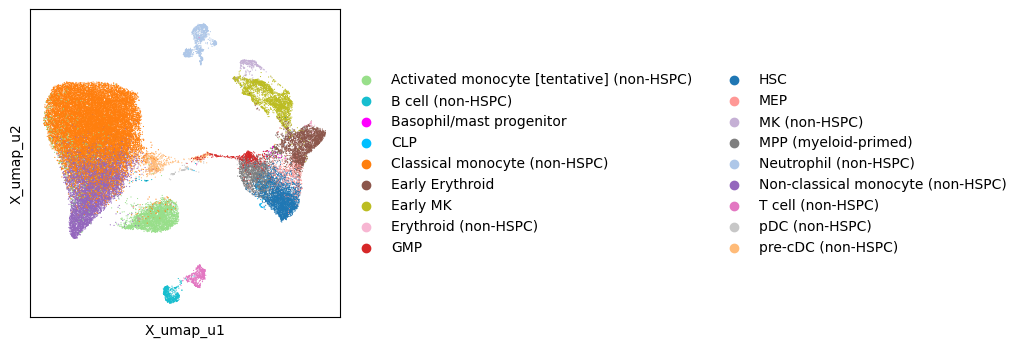

In [5]:
fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'cell_type', basis='X_umap_u', ax=ax, show=False, title='')

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_u_cell_types.pdf', dpi=300, bbox_inches='tight')

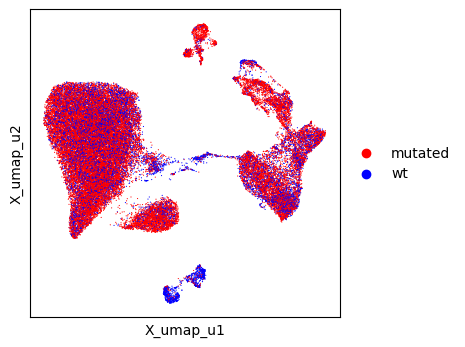

In [6]:
fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'genotype', basis='X_umap_u', ax=ax, show=False, title='')

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_u_genotype.pdf', dpi=300, bbox_inches='tight')

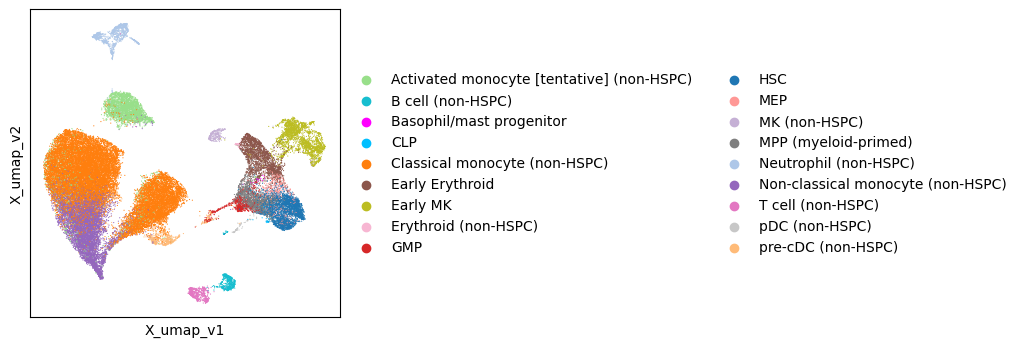

In [7]:
fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'cell_type', basis='X_umap_v', ax=ax, show=False, title='')

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_v_cell_types.pdf', dpi=300, bbox_inches='tight')

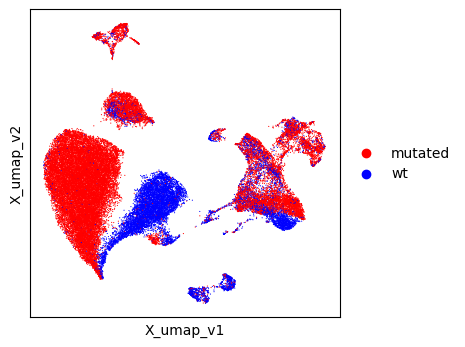

In [8]:
fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'genotype', basis='X_umap_v', ax=ax, show=False, title='')

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_v_genotype.pdf', dpi=300, bbox_inches='tight')

In [9]:
len(mrvi_adata)

45174

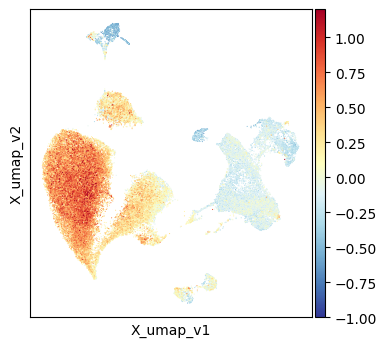

In [10]:
gene_set = pd.read_csv('../data/HALLMARK_INTERFERON_GAMMA_RESPONSE.v2025.1.Hs.tsv', sep='\t',index_col=0).loc['GENE_SYMBOLS'].values[0].split(',')
genes_present = []
for gene_name in gene_set:
    if gene_name in mrvi_adata.var_names:
        genes_present.append(gene_name)
geneset_id = [mrvi_adata.var_names.get_loc(j) for j in genes_present]

mrvi_adata.obs['ifn_gamma_score'] = np.mean(mrvi_adata.layers['zs_norm_log'][:, geneset_id], axis = 1)

fig,ax = plt.subplots(figsize=(4,4))
sc.pl.embedding(mrvi_adata, color = 'ifn_gamma_score', basis='X_umap_v', ax=ax, show=False, title = '', cmap = 'RdYlBu_r', vmin=-1, vmax=1.2)

# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_v_ifn_gamma.pdf', dpi=300, bbox_inches='tight')

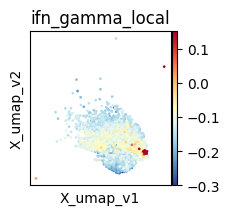

In [11]:
### Smooth IFN gamma score in HSCs using KNN graph; otherwise signal is too noisy to visualize

# --- 1) Extract HSC subset
hsc = mrvi_adata[mrvi_adata.obs['cell_type'] == 'HSC'].copy()

sc.pp.neighbors(hsc, n_neighbors=60, use_rep='v')  

# --- 2) Get score vector
x = hsc.obs['ifn_gamma_score'].values

# --- 3) Use neighbors graph to compute local mean
# If the HSC slice still contains neighbors graph:
G = hsc.obsp['connectivities']  # sparse matrix (cells x cells)

# Normalize rows to sum to 1
row_sums = np.array(G.sum(axis=1)).flatten()
G_norm = sp.diags(1 / row_sums) @ G

# Local smooth (KNN-weighted mean)
hsc.obs['ifn_gamma_local'] = G_norm @ x

# --- 4) Plot smoothed values

fig,ax = plt.subplots(figsize=(2,2))
sc.pl.embedding(
    hsc,
    basis='X_umap_v',
    color='ifn_gamma_local',
    cmap='RdYlBu_r',
    vmax=0.15, vmin=-0.3, ax=ax, show=False, s=15
)
# Get current axes and rasterize scatter points
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.savefig('../plots/mrvi_v_ifn_gamma_HSC.pdf', dpi=300, bbox_inches='tight')